# 2D Cross-Section Analysis of Mass Concentration

This notebook interpolates the predicted 3D data onto a 2D vertical cross-section plane between two points. It visualizes the final time step using the faster nearest-neighbor interpolation option.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.interpolate import griddata

In [3]:
# Define results directory and load data
results_dir = '/Users/arpitkapoor/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/Shared/Projects/10_Katana/04_groundwater/results/gino_predictions_20260117_131908'

val_preds = np.load(os.path.join(results_dir, 'val_predictions.npy'))
coords = pickle.load(open(os.path.join(results_dir, 'train_coords.pkl'), 'rb'))[0]

# Apply inverse coordinate transformation
coord_mean = np.array([357225.66528974305, 6457743.243307921, -9.277822477621577])
coord_std = np.array([569.1699998979727, 566.3579737855055, 15.2656561762675])
unnorm_coords = coords * coord_std + coord_mean

In [4]:
# Extract mass concentration for the last time step
# Reshape predictions to (N_nodes, T, N_vars)
if len(val_preds.shape) == 4:
    preds = np.squeeze(val_preds, axis=2).transpose(1, 0, 2)
else:
    preds = val_preds

# Index 0 is mass concentration, index -1 is the last time step
mass_conc_preds_last_step = preds[:, -1, 0]
print(f"Data shape for last time step: {mass_conc_preds_last_step.shape}")

Data shape for last time step: (10227,)


In [9]:
# Define Points P1 and P2
p1 = np.array([356835.28, 6459067.43])
p2 = np.array([357877.28, 6457548.86])

# Get Z bounds
z_min, z_max = unnorm_coords[:, 2].min(), unnorm_coords[:, 2].max()
print(f"Z range: [{z_min:.2f}, {z_max:.2f}]")

# Define the 2D grid resolution
num_horizontal_points = 10000
num_vertical_points = 5000

# Calculate distances along the line (s)
total_distance = np.linalg.norm(p2 - p1)
s_vals = np.linspace(0, total_distance, num_horizontal_points)

# Linearly interpolate X and Y coordinates along the horizontal transect
x_line = np.linspace(p1[0], p2[0], num_horizontal_points)
y_line = np.linspace(p1[1], p2[1], num_horizontal_points)
z_vals = np.linspace(z_min, z_max, num_vertical_points)

# Create meshes
S_grid, Z_grid = np.meshgrid(s_vals, z_vals)
X_grid, _ = np.meshgrid(x_line, z_vals)
Y_grid, _ = np.meshgrid(y_line, z_vals)

# Prepare target points for interpolation
grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel(), Z_grid.ravel()])

# Nearest neighbor interpolation (Fast option)
print("Interpolating data onto the 2D plane (using 'nearest' method)...")
cross_section_values = griddata(
    points=unnorm_coords, 
    values=mass_conc_preds_last_step, 
    xi=grid_points, 
    # method='nearest'
)

# Reshape back to the 2D grid dimensions
cross_section_grid = cross_section_values.reshape(S_grid.shape)
print("Interpolation completed.")

Z range: [-35.00, 33.87]
Interpolating data onto the 2D plane (using 'nearest' method)...
Interpolation completed.


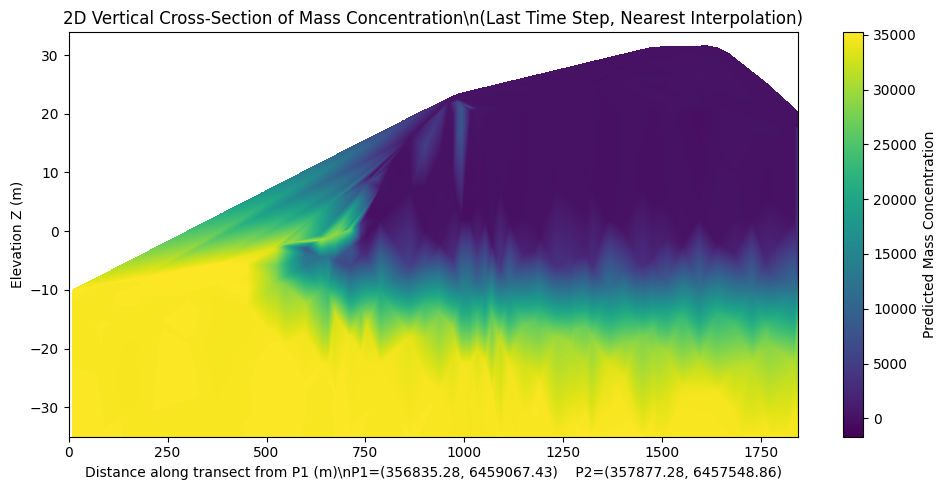

In [ ]:
# Plotting the Cross Section
plt.figure(figsize=(10, 5))

# Using pcolormesh is ideal for nearest neighbor visualization
pc = plt.pcolormesh(S_grid, Z_grid, cross_section_grid, cmap='viridis', shading='auto')
plt.colorbar(pc, label='Predicted Mass Concentration')

plt.title('2D Vertical Cross-Section of Mass Concentration\\n(Last Time Step, Nearest Interpolation)')
plt.xlabel(f'Distance along transect from P1 (m)\\nP1=({p1[0]:.2f}, {p1[1]:.2f})    P2=({p2[0]:.2f}, {p2[1]:.2f})')
plt.ylabel('Elevation Z (m)')

plt.tight_layout()
plt.show()